## Data preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import scipy.stats as stats
import os
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

Here I have imported libraries

In [3]:
df1=pd.read_csv('SEI06.20250503064657.csv')
df1.head()

,STATISTIC,Statistic Label,C02405V02899,Sector,TLIST(A1),Year,C02404V02898,Fuel Type,UNIT,VALUE
0,SEI06,Fuel Consumption (ktoe),14,Final energy consumption,1990,1990,01,Sum of all coal products,ktoe,843
1,SEI06,Fuel Consumption (ktoe),14,Final energy consumption,1990,1990,0101,Bituminous coal,ktoe,825
2,SEI06,Fuel Consumption (ktoe),14,Final energy consumption,1990,1990,0102,Anthracite and manufactured ovoids,ktoe,0
3,SEI06,Fuel Consumption (ktoe),14,Final energy consumption,1990,1990,0103,Coke,ktoe,0
4,SEI06,Fuel Consumption (ktoe),14,Final energy consumption,1990,1990,0104,Lignite,ktoe,18


In [8]:
df2=pd.read_excel('world-energy-use-1960-2012.xlsx')
df2.head()

,Year,Country,Population (People),GDP-PPP (Million Intl$ (2011)),GDP-USD (Million US$ (2010))
0,1997,Grenada,101122.0,7.827290e+02,515.773954
1,1997,Guatemala,10887634.0,6.260949e+04,26348.367642
2,1997,Haiti,8111951.0,1.404667e+04,6193.487030
3,1997,Honduras,6028882.0,2.034101e+04,9900.398522
4,1997,India,997405318.0,2.189208e+06,668870.101583


I have imported 2 datasets and this dataset saved in a variables as df1 and df2

In [9]:
print(df1.shape)
print(df2.shape)

(65340, 10)
(10615, 5)


these are the shapes of the datasets

In [10]:
print(df1.info())
print(df2.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65340 entries, 0 to 65339
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   STATISTIC        65340 non-null  object
 1   Statistic Label  65340 non-null  object
 2   C02405V02899     65340 non-null  int64 
 3   Sector           65340 non-null  object
 4   TLIST(A1)        65340 non-null  int64 
 5   Year             65340 non-null  int64 
 6   C02404V02898     65340 non-null  object
 7   Fuel Type        65340 non-null  object
 8   UNIT             65340 non-null  object
 9   VALUE            65340 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 5.0+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10615 entries, 0 to 10614
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            10615 non-null  int64  
 1   

Information of df1 and df2

In [11]:
print(df1.nunique())
print(df2.nunique())

STATISTIC             1
Statistic Label       1
C02405V02899         45
Sector               45
TLIST(A1)            33
Year                 33
C02404V02898         44
Fuel Type            44
UNIT                  1
VALUE              1319
dtype: int64
Year                                 55
Country                             193
Population (People)               10458
GDP-PPP (Million Intl$ (2011))     4483
GDP-USD (Million US$ (2010))       8072
dtype: int64


In unique method, how many unique values are present in one column are defined in df1 and df2 datasets

In [12]:
col=['STATISTIC','C02405V02899','TLIST(A1)','C02404V02898','Statistic Label','UNIT']

In [13]:
df1=df1.drop(columns=col)
df1.head()

,Sector,Year,Fuel Type,VALUE
0,Final energy consumption,1990,Sum of all coal products,843
1,Final energy consumption,1990,Bituminous coal,825
2,Final energy consumption,1990,Anthracite and manufactured ovoids,0
3,Final energy consumption,1990,Coke,0
4,Final energy consumption,1990,Lignite,18


In [14]:
df2=df2.drop(columns=['GDP-USD (Million US$ (2010))'])
df2.head()

,Year,Country,Population (People),GDP-PPP (Million Intl$ (2011))
0,1997,Grenada,101122.0,7.827290e+02
1,1997,Guatemala,10887634.0,6.260949e+04
2,1997,Haiti,8111951.0,1.404667e+04
3,1997,Honduras,6028882.0,2.034101e+04
4,1997,India,997405318.0,2.189208e+06


I have dropped the columns 'STATISTIC', 'Statistic Label', and 'UNIT' because they contain only one unique value and are therefore not useful for the machine learning process. Additionally, I removed the columns 'C02405V02899', 'TLIST(A1)', and 'C02404V02898' as they contain improperly structured data or are duplicates of existing columns. 

I removed the 'GDP-USD (Million US$ (2010)' column from df2,

because the 'GDP-PPP (Million Intl$ (2011))' column contains more updated values, so the former was no longer needed.

In [15]:
# Step 1: Aggregate fuel consumption data by Year
df_csv_grouped = df1.groupby('Year', as_index=False)['VALUE'].sum()
df_csv_grouped.rename(columns={'VALUE': 'Total Fuel Consumption (ktoe)'}, inplace=True)

# Step 2: Merge aggregated fuel consumption with economic, demographic data on 'Year'
df = pd.merge(df2, df_csv_grouped, on='Year', how='inner')

df.head()

,Year,Country,Population (People),GDP-PPP (Million Intl$ (2011)),Total Fuel Consumption (ktoe)
0,1997,Grenada,101122.0,7.827290e+02,70508
1,1997,Guatemala,10887634.0,6.260949e+04,70508
2,1997,Haiti,8111951.0,1.404667e+04,70508
3,1997,Honduras,6028882.0,2.034101e+04,70508
4,1997,India,997405318.0,2.189208e+06,70508


In [16]:
df.shape

(4825, 5)

In this code, firstly, total fuel consumption is computed for each year by summing the 'VALUE' column in df1 and renaming it.

Next, it merges that yearly fuel consumption with demographic data in df2 on the common 'Year' column to form a joined data set df. And in Total Fuel Consumption (ktoe). I 

This methodology achieves a single data set for analysis by pairing the fuel usage with that year's economic and demographic indicators.
And the Shape of df=(4825, 5)

In [17]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

Using the **median** to fill missing numbers is a wise and safe choice because the median is unaffected by outlying extreme values and usually represents a data value from the middle of the data. This balance preserves the actual data; hence, the median becomes the preferred choice when one is unsure about the data or if it contains outliers.

In [18]:
# df.to_csv("Optimized_data.csv", index=False)

In [19]:
# df.to_csv("before_data.csv", index=False)

In [25]:
memory_before= df_before.memory_usage(deep=True).sum()/1024 ** 2  # in MB
memory_before

0.412017822265625

In [20]:
# Before Optimization 
start_time_before= time.time()
df_before=df
end_time_before=time.time()
time_before=end_time_before-start_time_before
memory_before= df_before.memory_usage(deep=True).sum()/1024 ** 2  # in MB

print("BEFORE OPTIMIZATION")
print(df_before.info())
print(f"Time to load: {time_before:.4f} seconds")
print(f"Memory usage: {memory_before:.4f} MB")

BEFORE OPTIMIZATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4825 entries, 0 to 4824
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            4825 non-null   int64  
 1   Country                         4825 non-null   object 
 2   Population (People)             4825 non-null   float64
 3   GDP-PPP (Million Intl$ (2011))  4825 non-null   float64
 4   Total Fuel Consumption (ktoe)   4825 non-null   int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 188.6+ KB
None
Time to load: 0.0000 seconds
Memory usage: 0.4120 MB


It measures the loading time and memory usage of the loading of the original DataFrame `df` into `df_before` before any optimization occurs. 

It prints the data structure, loading time, and memory in MB as a basis of comparison.

In [26]:
start_time_after = time.time()
df_optimized = df_before.copy()

# Optimize integer columns
for col in df_optimized.select_dtypes(include=['int64', 'int']).columns:
    df_optimized[col] = pd.to_numeric(df_optimized[col], downcast='integer')

# Optimize float columns 
for col in df_optimized.select_dtypes(include=['float']).columns:
    if (df_optimized[col] % 1 == 0).all():
        df_optimized[col] = df_optimized[col].astype('int')
    else:
        df_optimized[col] = df_optimized[col].round().astype('int')

# Optimize object columns
df_optimized["Country"] = df_optimized["Country"].astype("category")

end_time_after = time.time()
time_after = end_time_after - start_time_after
memory_after = df_optimized.memory_usage(deep=True).sum() / 1024 ** 2  # MB

print("AFTER OPTIMIZATION")
print(df_optimized.info())
print(f"Time to optimize: {time_after:.4f} seconds")
print(f"Memory usage: {memory_after:.4f} MB")

# df_optimized.to_csv("Optimized_data.csv", index=False)

AFTER OPTIMIZATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4825 entries, 0 to 4824
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Year                            4825 non-null   int16   
 1   Country                         4825 non-null   category
 2   Population (People)             4825 non-null   int32   
 3   GDP-PPP (Million Intl$ (2011))  4825 non-null   int32   
 4   Total Fuel Consumption (ktoe)   4825 non-null   int32   
dtypes: category(1), int16(1), int32(3)
memory usage: 81.1 KB
None
Time to optimize: 0.0161 seconds
Memory usage: 0.0883 MB


This code takes the memory optimization route: it works on a copy, `df_optimized`, of the pre-optimized DataFrame, `df_before`,

downcasting data types where it can. It downcasts integer columns first to the smallest possible integer type (`int8`, `int16`, etc.) using `pd.to_numeric`. 

Then, for each float column, if all values are whole numbers it converts them to integers, otherwise it rounds the numbers before conversion. The 'Country' column, which is of type object (string), is converted to the category type in order to reduce memory.

prints the time taken and total memory optimization.

In [27]:
df=df_optimized
df.head()

,Year,Country,Population (People),GDP-PPP (Million Intl$ (2011)),Total Fuel Consumption (ktoe)
0,1997,Grenada,101122,783,70508
1,1997,Guatemala,10887634,62609,70508
2,1997,Haiti,8111951,14047,70508
3,1997,Honduras,6028882,20341,70508
4,1997,India,997405318,2189208,70508


This df is after optimization

In [28]:
# Tufte-style visuals
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

def tufte_plot(ax, title, xlabel, ylabel):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_prop_cycle(color=sns.color_palette("deep"))
    return ax


The above code is to implement a clean Tufte-style figure in Python that performs plotting with Matplotlib and Seaborn libraries for clear, readable visualisation of data. 

The original code sets the `seaborn-v0_8-whitegrid` style, as well as the deep palette color for filling, and modifies various other settings globally. 

The custom `tufte_plot` function makes a custom look for a plot axis. This is done by removing the top and right spine, which removes a source of visual clutter, setting the x- and y-axis label text, creating a bold title, and adding a light, dashed grid for style and readability. 

This demonstrates Tufte's philosophy of clarity in the data that is presented, and the less visual clutter.


In [32]:
print("Missing Data Analysis")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_pct
print(df.duplicated().sum())

Missing Data Analysis
0


here df has no null values, no Dunlicate values. 

In [34]:
df.describe()

,Year,Population (People),GDP-PPP (Million Intl$ (2011)),Total Fuel Consumption (ktoe)
count,4825.00000,4.825000e+03,4.825000e+03,4825.000000
mean,2002.00000,2.375801e+07,7.976519e+05,86002.440000
std,7.21185,2.025444e+08,5.365802e+06,17630.539732
min,1990.00000,-2.147484e+09,2.100000e+01,58467.000000
25%,1996.00000,1.697101e+06,1.095600e+04,67230.000000
50%,2002.00000,7.152385e+06,3.988700e+04,93479.000000
75%,2008.00000,2.124920e+07,2.270210e+05,99183.000000
max,2014.00000,1.364270e+09,1.022958e+08,111264.000000


summary statistics for all numeric columns in the DataFrame `df`. It includes count, mean, standard deviation, minimum, 25th percentile, median (50%), 75th percentile, and maximum values, helping you understand the distribution and range of your data.


### Numerical Analysis

Distributions of Key Numeric Attributes


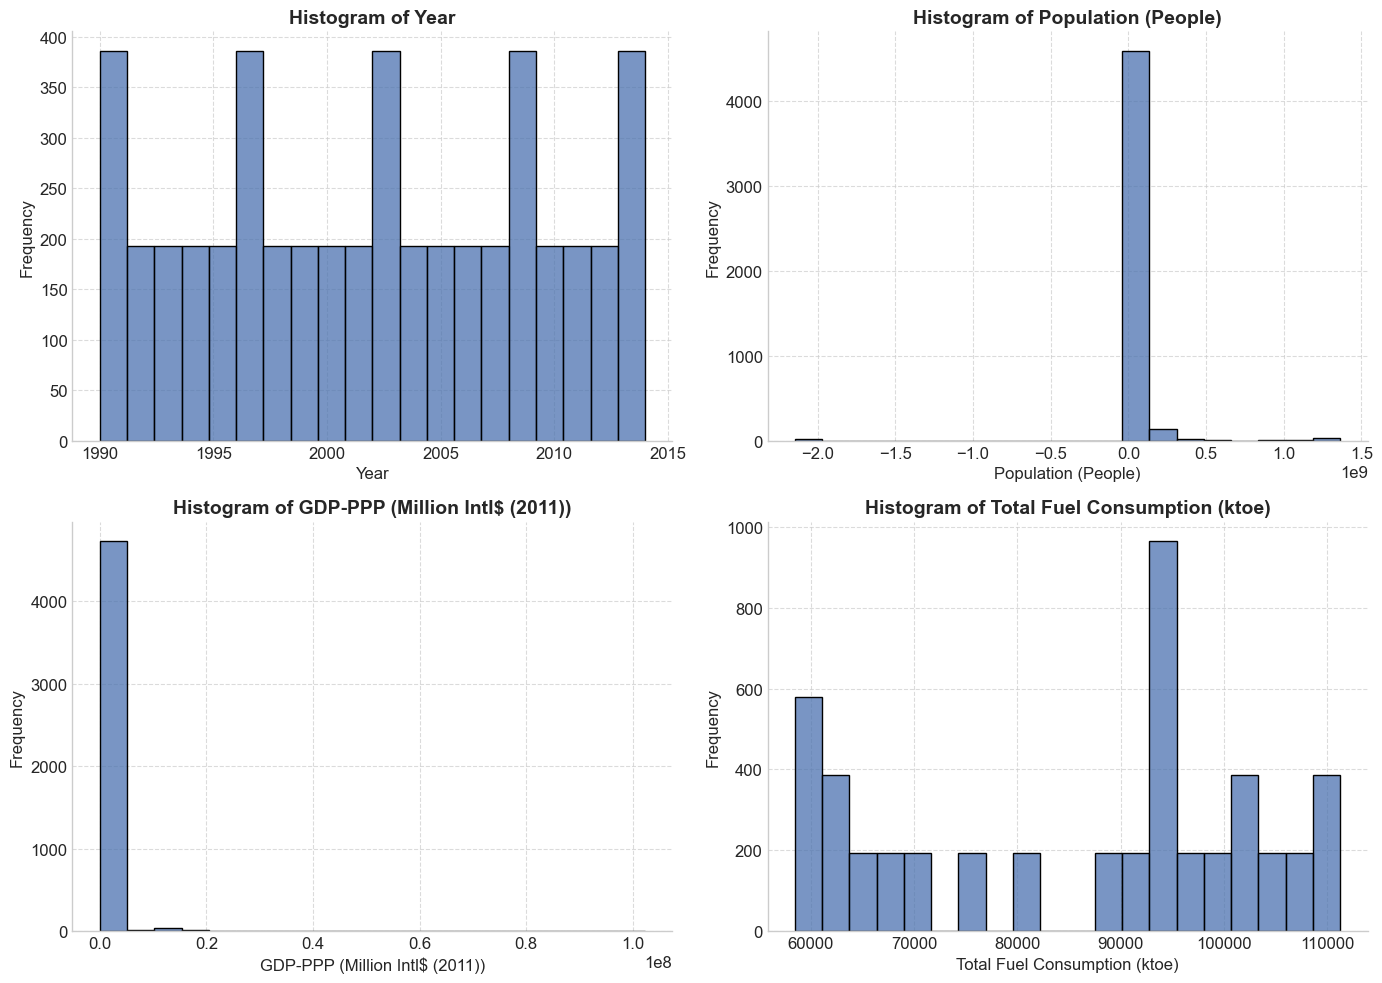

In [37]:
print("Distributions of Key Numeric Attributes")
numeric_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=20, edgecolor='black', ax=axes[i])
    axes[i] = tufte_plot(axes[i], f'Histogram of {col}', col, 'Frequency')

plt.tight_layout()
plt.show()

# plt.savefig('Histogram1.png')
# plt.close()

This code generates histograms to visualize the distributions of key numeric columns in the DataFrame df.

It selects numeric columns, sets up a 2x2 grid of subplots, and plots each using Seaborn for clear visuals, it plots a histogram using Seaborn and applies the `tufte_plot` styling for a clean, readable layout. 

It helps for me to analyze the empirical distribution of each numeric variable.

Boxplots to Detect Outliers


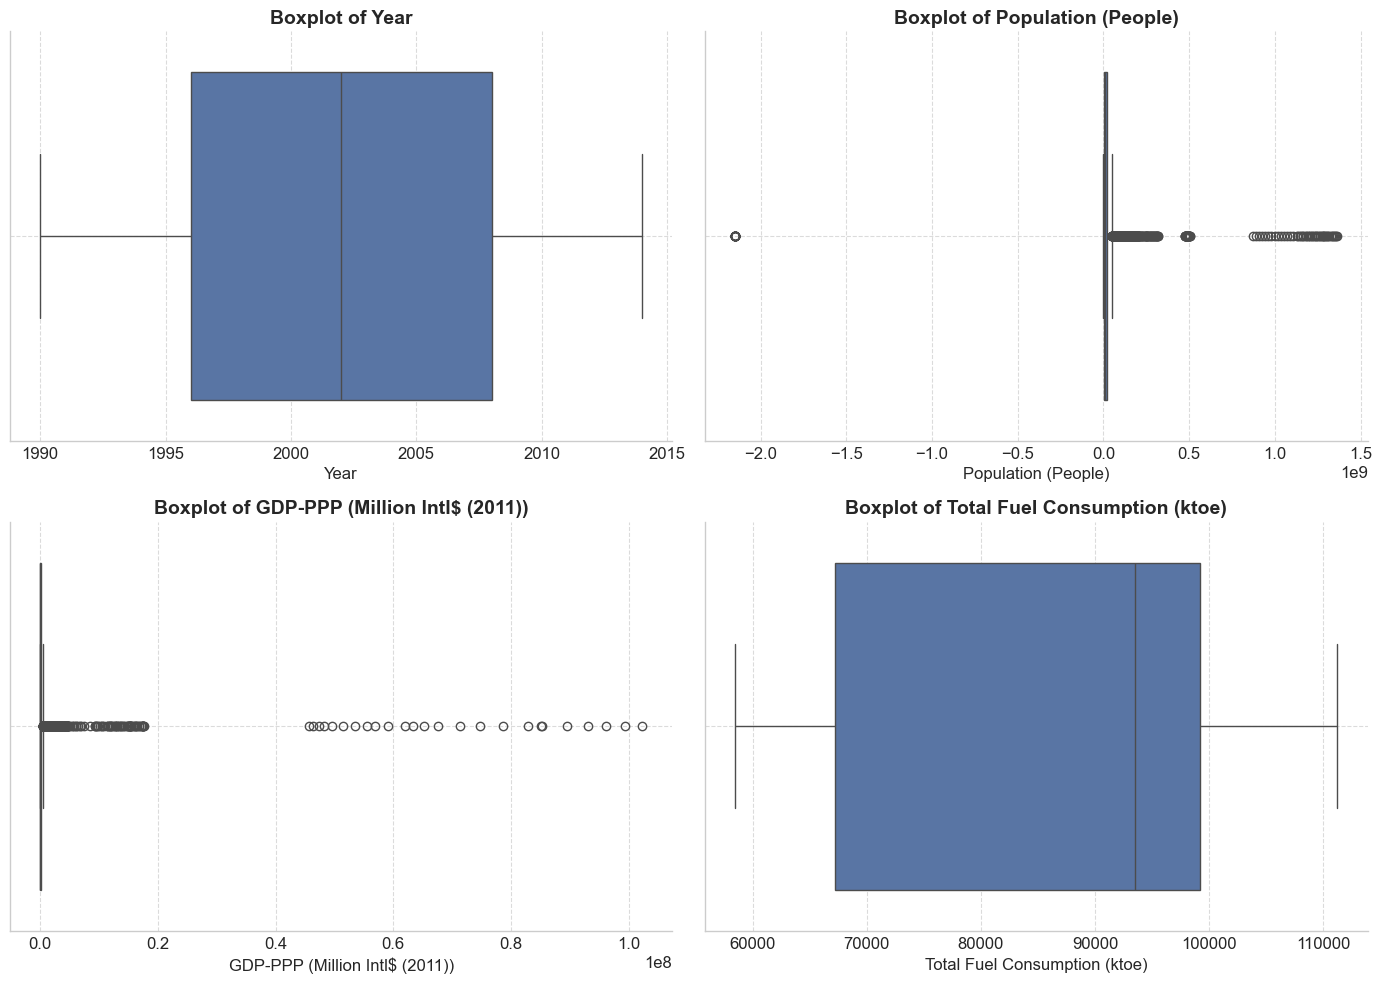

In [39]:
print("Boxplots to Detect Outliers")

numeric_cols = df.select_dtypes(include='number').columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) 
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i] = tufte_plot(axes[i], f'Boxplot of {col}', col, '')

plt.tight_layout()
plt.show()

# plt.savefig('BOXWO.png')
# plt.close()

This code generates boxplots for each numeric column in the DataFrame `df` to help detect outliers. 
  
  Boxplots show the distribution, median, and potential outliers in each numeric feature.

Original rows: 4825, After outlier removal: 4015


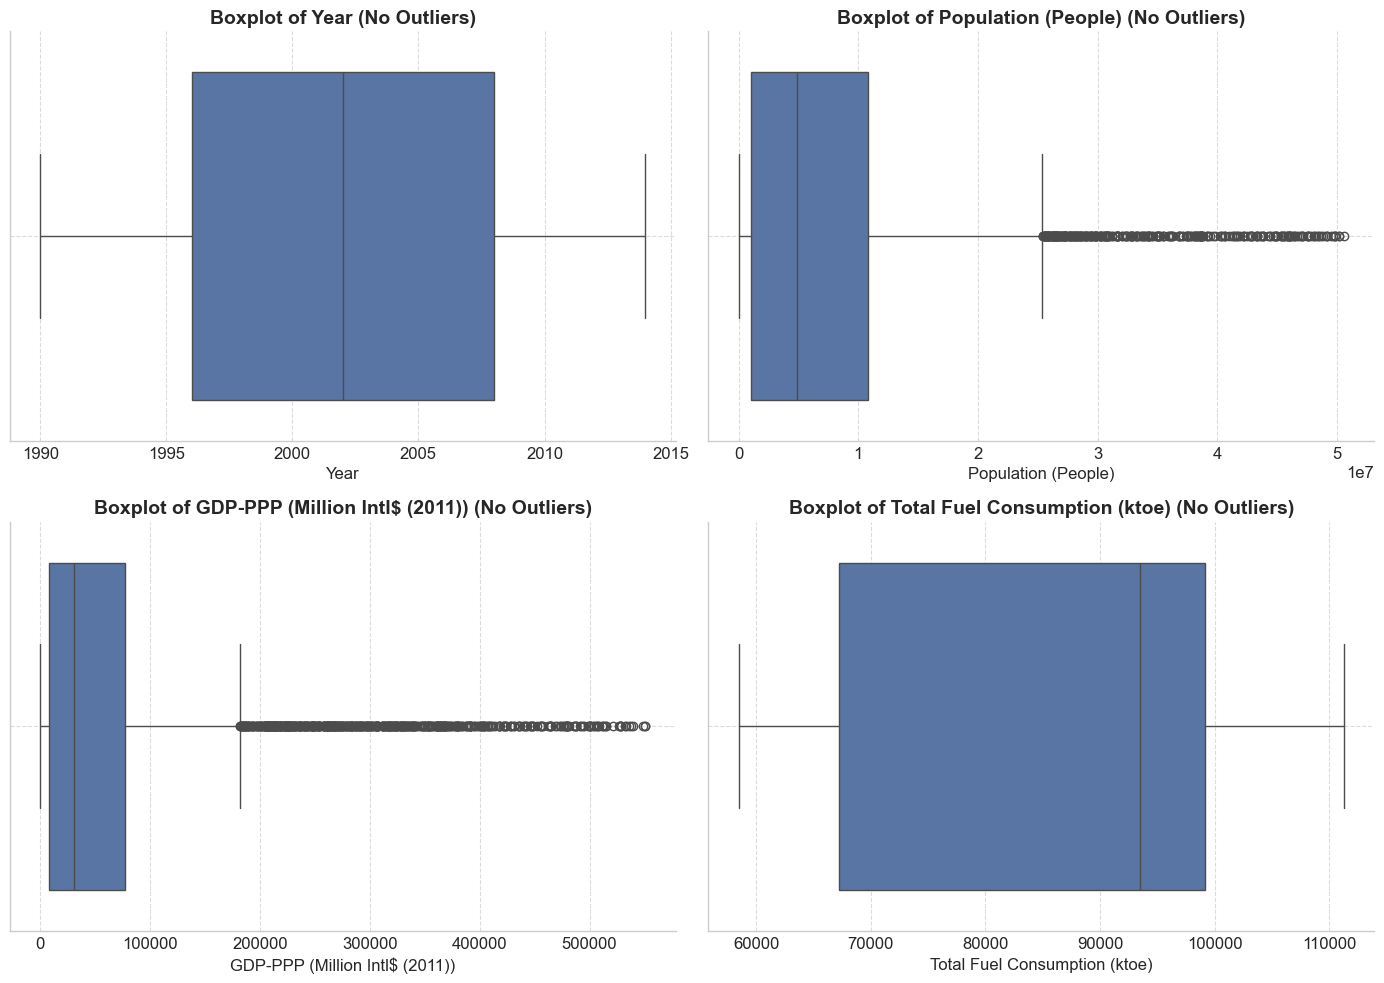

In [41]:
def remove_outliers_iqr(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - k * IQR, Q3 + k * IQR
        # Keep rows where col is within [lower, upper]
        mask &= df[col].between(lower, upper)
    return df.loc[mask]

numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Apply outlier removal
df_no_outliers = remove_outliers_iqr(df, numeric_cols)
print(f"Original rows: {df.shape[0]}, After outlier removal: {df_no_outliers.shape[0]}")

# plot Boxplots to Validate
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_no_outliers[col], ax=axes[i])
    tufte_plot(axes[i], f'Boxplot of {col} (No Outliers)', col,'')

plt.tight_layout()
plt.show()

# plt.savefig('BOXOUT.png')
# plt.close()

This code removes outliers from a dataset using the Interquartile Range (IQR) method, which filters out values that fall outside 1.5 times the IQR from the first and third quartiles. 

It applies this method to all numeric columns in the DataFrame and returns only rows where all values are within the acceptable range. After filtering, it prints how many rows remain to show the impact of outlier removal. It then creates boxplots for each numeric column to visually confirm that outliers have been successfully removed. Finally, the cleaned dataset replaces the original for further analysis or visualization.


Correlation Analysis


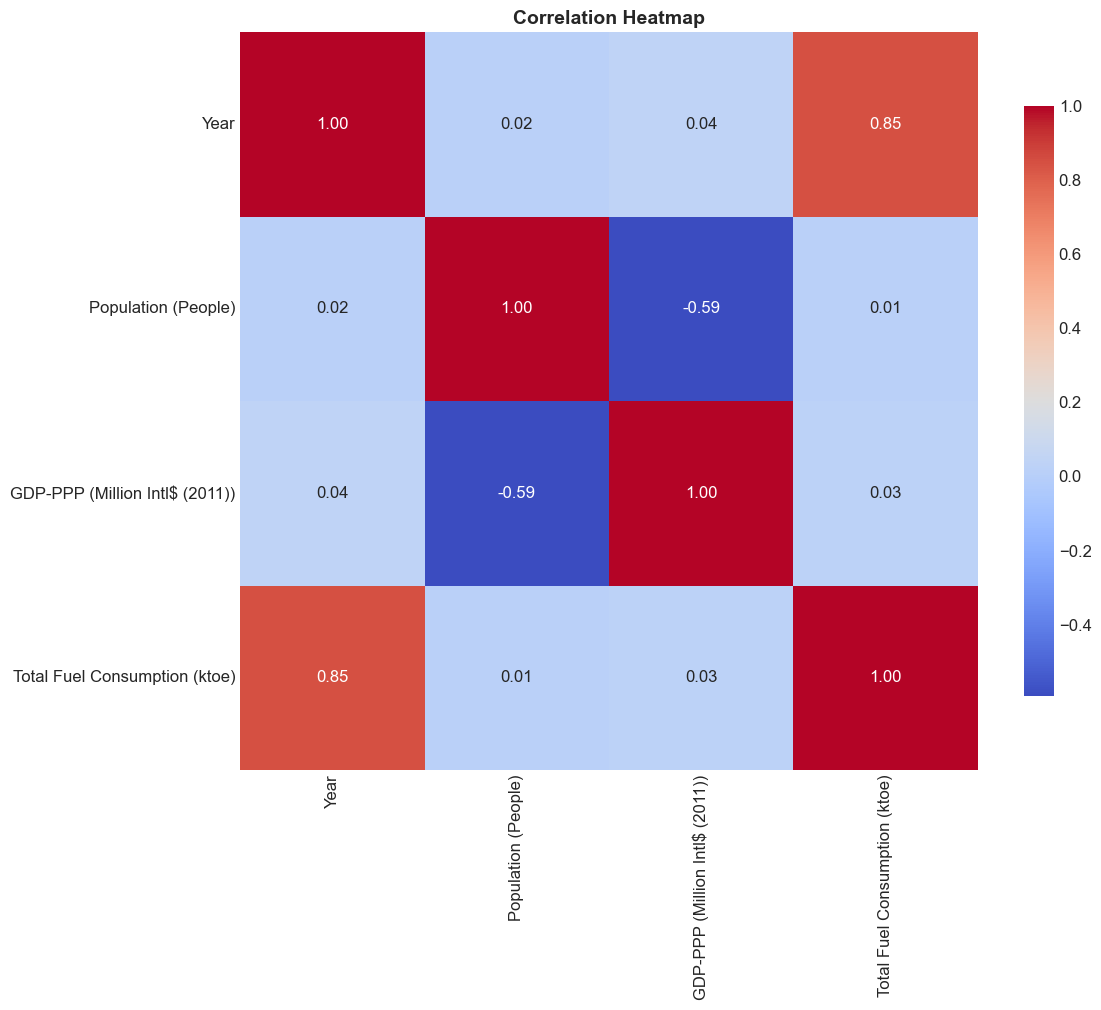

In [43]:
print("Correlation Analysis")
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax = tufte_plot(ax, 'Correlation Heatmap', '', '')
plt.tight_layout()
plt.show()

# plt.savefig('CORRILATION.png')
# plt.close()

Correlation analysis of the numeric columns in the DataFrame `df` to understand how strongly they relate to each other. It calculates the correlation matrix and displays it as a heatmap using Seaborn, where color intensity and values indicate the strength and direction of relationships. 

The heatmap is styled with the `tufte_plot` function to enhance readability. This helps identify highly correlated features, which can inform feature selection.


### both categorical and Numerical Analysis

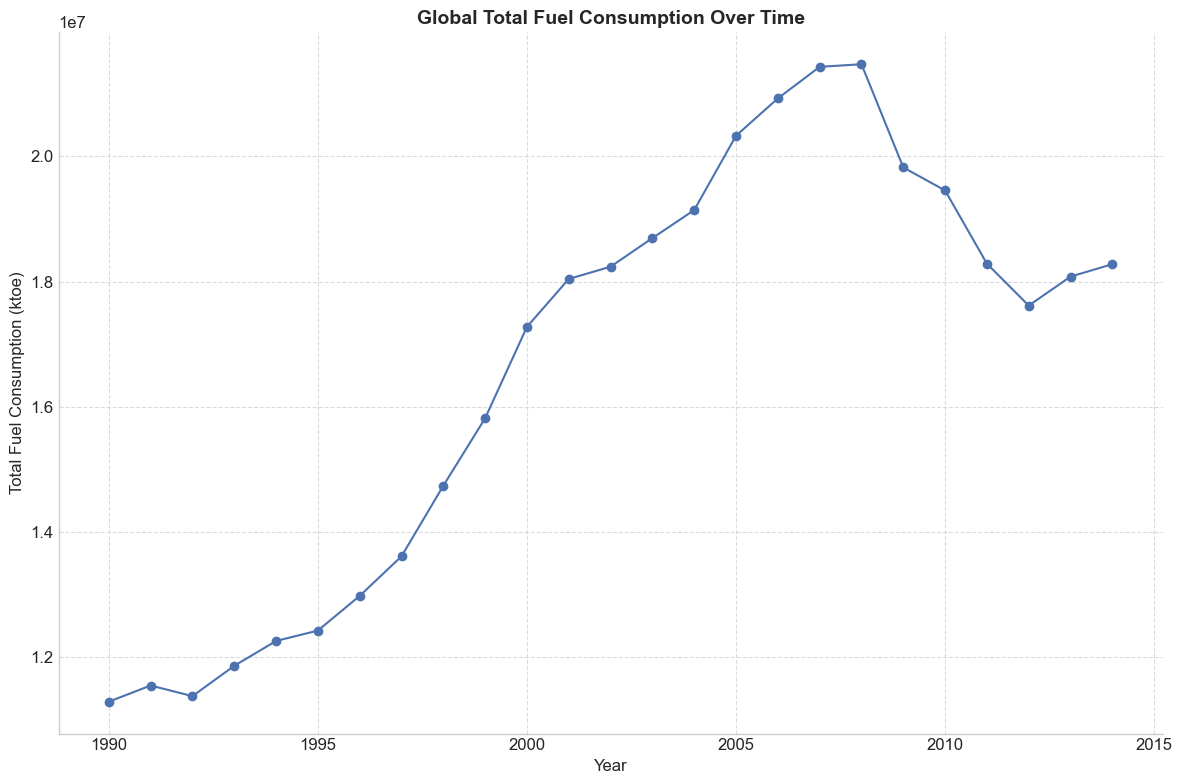

In [46]:
annual_total = (
    df
    .groupby('Year')['Total Fuel Consumption (ktoe)']
    .sum()
    .reset_index()
)

# Plot
fig, ax = plt.subplots()
ax.plot(
    annual_total['Year'],
    annual_total['Total Fuel Consumption (ktoe)'],
    marker='o',
    linestyle='-'
)
tufte_plot(
    ax,
    'Global Total Fuel Consumption Over Time',
    'Year',
    'Total Fuel Consumption (ktoe)'
)
plt.tight_layout()
plt.show()

# plt.savefig('LINE.png')
# plt.close()

The global total fuel consumption for each year by grouping the data by the "Year" column and summing the values of "Total Fuel Consumption (ktoe)". The result is a time series showing annual totals. 

It helps for me analyze the trend (e.g., regression slope significance) to infer whether consumption is increasing or decreasing in the population, beyond random year‑to‑year fluctuations.

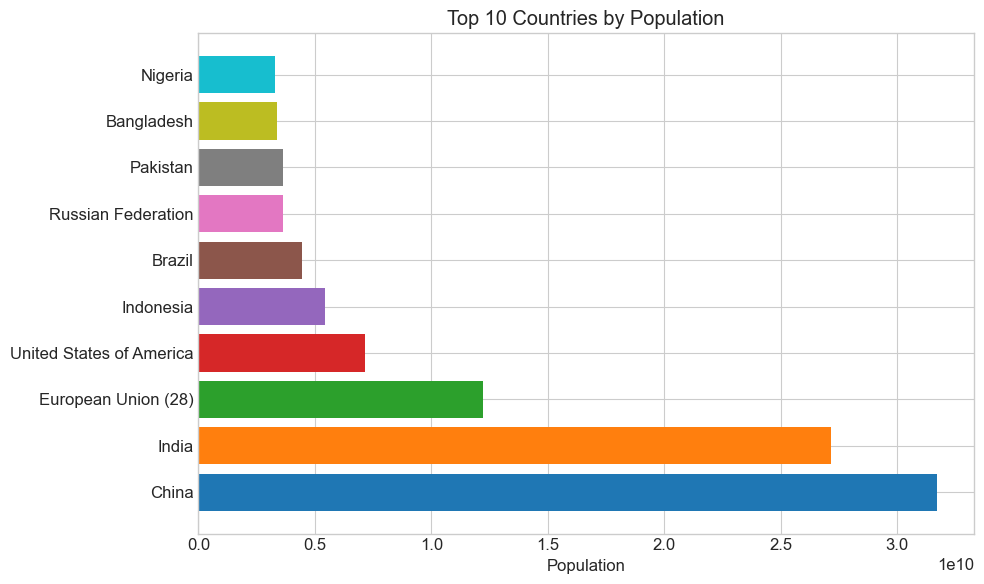

In [48]:
top_pop = df.groupby('Country')['Population (People)'].sum().nlargest(10)
colors = plt.cm.tab10.colors  
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10.colors  
plt.barh(top_pop.index, top_pop.values, color=colors[:len(top_pop)]) 
plt.title('Top 10 Countries by Population')
plt.xlabel('Population')
plt.tight_layout()
plt.show()

# plt.savefig('TOP10.png')
# plt.close()

horizontal bar chart showing the top 10 countries by population using `matplotlib`, with each bar in a different color from the `tab10` colormap. It sets figure size, labels, and layout for better readability and presentation.


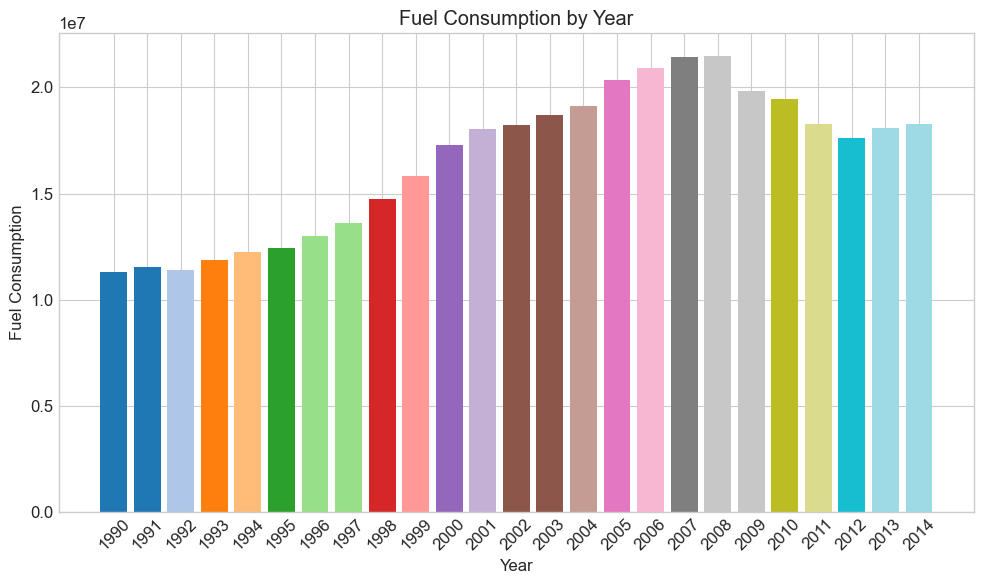

In [50]:
fuel_year = df.groupby('Year')['Total Fuel Consumption (ktoe)'].sum()
cmap = plt.cm.get_cmap('tab20', len(fuel_year))
colors = [cmap(i) for i in range(len(fuel_year))]
plt.figure(figsize=(10, 6))
plt.bar(fuel_year.index.astype(str), fuel_year.values, color=colors)
plt.title('Fuel Consumption by Year')
plt.xlabel('Year')
plt.ylabel('Fuel Consumption')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()
# plt.savefig('BARCHART.png')
# plt.close()

This code generates a vertical bar chart displaying total fuel consumption by year, with each bar colored differently using the `tab20` colormap. It groups and sums the data by year.
This graph can also help with analysis and provide valuable insights for developing an unsupervised machine learning model using clustering.

## Dashboards

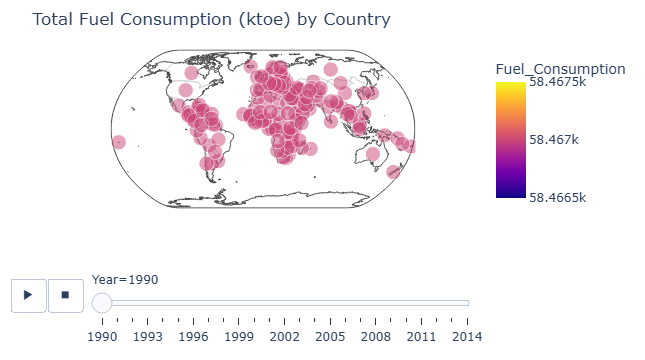

In [53]:
df.rename(columns={
    'Total Fuel Consumption (ktoe)': 'Fuel_Consumption',
    'Population (People)': 'Population',
    'GDP-PPP (Million Intl$ (2011))': 'GDP_PPP'
}, inplace=True)

year_order = df['Year'].sort_values(ascending=True).unique()

fig_fuel_scatter = px.scatter_geo(
    df,
    locations="Country",
    locationmode="country names",
    size="Fuel_Consumption",
    size_max=15,
    color="Fuel_Consumption",
    hover_name="Country",
    hover_data={
        "Population": True,
        "GDP_PPP": ':.2f',
        "Fuel_Consumption": ':.1f'
    },
    animation_frame="Year",
    projection="natural earth",
    title="Total Fuel Consumption (ktoe) by Country",
    opacity=0.5,
    category_orders={"Year": year_order}        
)

# Tufte-style cleanup
fig_fuel_scatter.update_layout(
    geo=dict(
        showland=True, landcolor="white",
        showcountries=True, countrycolor="lightgrey",
        showocean=False
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=10, r=10, t=50, b=10),
    legend=dict(
        title="Fuel (ktoe)",
        itemsizing='constant',
        borderwidth=0
    )
)

fig_fuel_scatter.show()
# fig_fuel_scatter.write_html('Fuel_Consumption_BUBBLE_MAP.html')


**bubble map** of total fuel consumption by country over time using Plotly. And changing according to the time period

First, it renames columns in the DataFrame for easier reference (`Fuel_Consumption`, `Population`, and `GDP_PPP`). 

It then builds a geographic scatter plot where each country's bubble size and color represent its total fuel consumption, with tooltips showing population and GDP. 

The map is animated by year, uses the “natural earth” projection, and applies semi-transparency to the bubbles for clarity. Finally, the map’s layout is cleaned up in a minimalist **Tufte-style**, using white backgrounds.


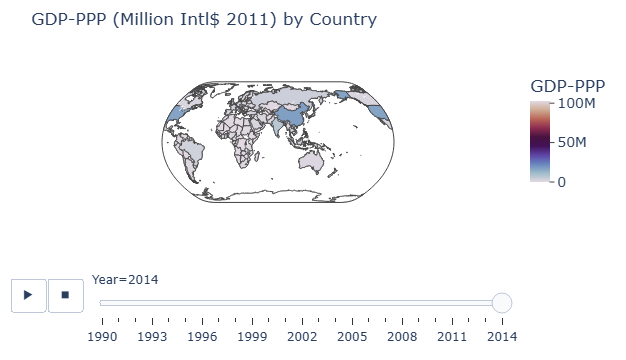

In [55]:
year_order = df['Year'].sort_values(ascending=True).unique()

df.rename(columns={
    'GDP-PPP (Million Intl$ (2011))': 'GDP_PPP',
    'Total Fuel Consumption (ktoe)': 'Fuel_Consumption',
    'Population (People)': 'Population'
}, inplace=True)

fig_gdp = px.choropleth(
    df,
    locations="Country",
    locationmode="country names",
    color="GDP_PPP",
    hover_name="Country",
    hover_data={
        "Population": True,
        "Fuel_Consumption": True,
        "GDP_PPP": ':.2f'
    },
    animation_frame="Year",
    category_orders={"Year": year_order},    
    color_continuous_scale='twilight',
    title="GDP-PPP (Million Intl$ 2011) by Country"
)

# Tufte-style 
fig_gdp.update_layout(
    geo=dict(
        projection={'type': 'natural earth'},
        showland=True, landcolor="white",
        showcountries=True, countrycolor="lightgrey",
        showocean=False
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=10, r=10, t=50, b=10),
    coloraxis_colorbar=dict(
        title="GDP-PPP",
        thickness=20,      
        len=0.8,           
        outlinewidth=0,
        ticks="outside",
        tickfont=dict(size=14)  
    )
)

fig_gdp.show()
# fig_gdp.write_html('GDP-PPP_CHOROPLETH_MAP.html')


**Choropleth map** to visualize GDP-PPP across countries over time. It first renames relevant columns for clarity (`GDP_PPP`, `Fuel_Consumption`, and `Population`). 

The choropleth uses country names for mapping and colors each country based on its GDP-PPP value, with interactive hover data showing population and fuel consumption. It includes an **animated time slider** by year and applies a 'twilight' color scale for visual impact. The layout is styled in a clean, **Tufte-inspired format** with a natural earth projection.


## Before Machine Learning

In [58]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

log_transform_cols = ['Population', 'GDP_PPP', 'Fuel_Consumption']
for col in log_transform_cols:
    df[col] = np.log1p(df[col])  
    
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])

scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df)

df.head()

,Year,Country,Population,GDP_PPP,Fuel_Consumption
0,-0.693375,-0.502571,-1.822284,-1.672955,-0.809348
1,-0.693375,-0.484622,0.338103,0.157245,-0.809348
2,-0.693375,-0.412826,0.202225,-0.467176,-0.809348
3,-0.693375,-0.394877,0.065199,-0.312492,-0.809348
4,-0.693375,-0.341030,2.423916,1.642361,-0.809348


The code is preparing a dataset for machine learning purposes through the transformation and standardization of its features.

It first applies a **log transformation** to the unintentionally skewed numerical columns (Population, GDP_PPP, and Fuel_Consumption) in order to reduce their skewness and also effectively deal with 0 values. 

It then uses **label encoding** to transform the categorical character column 'Country' into numeric format while also reducing the dimensionality of the dataset. 

After that, the code employs **standardization** to standardize the numerical features so they have a mean of 0, and a standard deviation of 1 for all numerical features. The code finishes by displaying the first few rows of the transformed DataFrame.

#### Ready for machine learning part